# Animal Shelter: Data Preparation

This notebook loads, cleans, and merges the Austin Animal Center 
intake and outcome datasets. The resulting merged DataFrame is 
saved as a pickle file for use in subsequent analysis.

Data source: "https://www.kaggle.com/datasets/thedevastator/austin-animal-center-data"

In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option("display.float_format", "{:,.2f}".format)

I **restrict myself to dogs** and drop for this investigation all other animals from the dataset 

**Intake:** each line of the dataset describes an animal, which has ben brought into the shelter.
    
Number of column | Name of column | Datatype | Description
:---|:---|:---|:----  
1  |  `'Animal ID'` | categorical (nominal) | Unique indentification number of the animal
2  |  `'Name'` | categorical (`string`) | Name of the animal 
3  |  `'DateTime'` | continuous (`Datetime`) | Date and time when the animal was brought to shelter
4  |  `'MonthYear'` | contiuous (`string` + `int`) |Month and Year of intake 
5  |  `'Found Location'` | categorical (`string`) | Adress: found location or home adress
6  |  `'Intake Type'` | categorical (`string`) | How/why animal came to shelter
7  |  `'Intake Condition'` | categorical (`string`) | Health and body condition
8  |  `'Animal Type'` | categorical (`string`) | kind of animal
9  |  `'Sex upon intake'` | categorical (`string`) | gender and sex
10  |  `'Age upon intake'` | continous (`string`) | age X years/ Y month
11  |  `'Breed'` | categorical (`string`) | Breed of animal
12  |  `'Color'` | categorical (`string`) | Color of fur 


**Outcome:** each line of the dataset describes an animal, which left the shelter.
    
Number of column | Name of column | Datatype | Description
:---|:---|:---|:----  
1  |  `'Animal ID'` | categorical (nominal) | Unique indentification number of the animal
2  |  `'Name'` | categorical (`string`) | Name of the animal 
3  |  `'DateTime'` | continuous (`Datetime`) | Date and time when the animal left the shelter
4  |  `'MonthYear'` | contiuous (`string` + `int`) |Month and Year of outcome 
5  |  `'Outcome Type'` | categorical (`string`) | How it came out (Adoption...)
6  |  `'Outcome Subtype'` | categorical (`string`) | Further information of how it came out (Foster...)
7  |  `'Animal Type'` | categorical (`string`) | kind of animal
8  |  `'Sex upon Outcome'` | categorical (`string`) | gender and sex
10  |  `'Age upon Outcome'` | continous (`string`) | age X years/ Y month
11  |  `'Breed'` | categorical (`string`) | Breed of animal
12  |  `'Color'` | categorical (`string`) | Color of fur 


## 1. Load Data

Loading intake and outcome datasets. Filtering for dogs only, 
dropping the Animal Type column. 

The dataset contains 157,628 rows, each of which describes an event associated with an animal. However, this does not mean that there are 157,628 animals, since an animal may be admitted to the shelter more than once. Of these cases, 87,192 involve dogs. That means about 55% of the entire dataset is included in my analysis.

In [2]:
#read data and select dogs + drop animal-Type
df_in = pd.read_csv("archive/AustinAnimalCenterIntakes.csv")
print(f"{df_in.shape[0]} animals in data")
df_in = df_in[df_in["Animal Type"] == "Dog"]
df_in = df_in.drop("Animal Type", axis = 1)
print(f"{df_in.shape[0]} dogs in data")
df_in.head()

157628 animals in data
87192 dogs in data


,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Sex upon Intake,Age upon Intake,Breed,Color
0,A786884,*Brock,01/03/2019 04:19:00 PM,January 2019,2501 Magin Meadow Dr in Austin (TX),Stray,Normal,Neutered Male,2 years,Beagle Mix,Tricolor
1,A706918,Belle,07/05/2015 12:59:00 PM,July 2015,9409 Bluegrass Dr in Austin (TX),Stray,Normal,Spayed Female,8 years,English Springer Spaniel,White/Liver
2,A724273,Runster,04/14/2016 06:43:00 PM,April 2016,2818 Palomino Trail in Austin (TX),Stray,Normal,Intact Male,11 months,Basenji Mix,Sable/White
4,A682524,Rio,06/29/2014 10:38:00 AM,June 2014,800 Grove Blvd in Austin (TX),Stray,Normal,Neutered Male,4 years,Doberman Pinsch/Australian Cattle Dog,Tan/Gray
5,A743852,Odin,02/18/2017 12:46:00 PM,February 2017,Austin (TX),Owner Surrender,Normal,Neutered Male,2 years,Labrador Retriever Mix,Chocolate


In [3]:
df_out = pd.read_csv("archive/AustinAnimalCenterOutcomes.csv")
df_out = df_out[df_out["Animal Type"] == "Dog"]
df_out = df_out.drop("Animal Type", axis = 1)
df_out.head(5)

,Animal ID,Name,DateTime,MonthYear,Date of Birth,Outcome Type,Outcome Subtype,Sex upon Outcome,Age upon Outcome,Breed,Color
1,A776359,Gizmo,07/18/2018 04:02:00 PM,Jul 2018,07/12/2017,Adoption,NaN,Neutered Male,1 year,Chihuahua Shorthair Mix,White/Brown
3,A720371,Moose,02/13/2016 05:59:00 PM,Feb 2016,10/08/2015,Adoption,NaN,Neutered Male,4 months,Anatol Shepherd/Labrador Retriever,Buff
5,A659412,Princess,10/05/2020 02:37:00 PM,Oct 2020,03/24/2013,Adoption,NaN,Spayed Female,7 years,Chihuahua Shorthair Mix,Brown
6,A814515,Quentin,05/06/2020 07:59:00 AM,May 2020,03/01/2018,Adoption,Foster,Neutered Male,2 years,American Foxhound/Labrador Retriever,White/Brown
10,A840370,Tulip,08/19/2021 07:36:00 PM,Aug 2021,08/06/2019,Adoption,NaN,Spayed Female,2 years,Border Collie/Cardigan Welsh Corgi,Black/White


## 2. Data Overview

Custom function to inspect dtypes, missing values, and cardinality.

In [4]:
def getOverview(df):
    '''Returns summary about the data in the dataframe.

        Creates a dataFrame with datatypes, unique, nunique, number of missing values; 
               
        Args:
            df (pandas.dataFrame): a dataframe with rows and columns

        Returns:
            None
    '''
    df = df.copy()
    display(pd.DataFrame({'dtype': df.dtypes,                                   # Dtypes
                          'total': df.count(),                                  # number of valid entries
                          'missing_n': df.isna().sum(),                         # Number nan-entries
                          'missing_%': df.isna().mean()*100,                    # Ratio of missing values in %
                          'uniques_n': df.nunique(),                            # Caridinality (Number of unique values)
                          'uniques': [df[col].unique() for col in df.columns]   # List of unique values
                         }))

In [5]:
getOverview(df_in)
getOverview(df_out)

,dtype,total,missing_n,missing_%,uniques_n,uniques
Animal ID,str,87192,0,0.00,73783,"[A786884, A706918, A724273, A682524, A743852, ..."
Name,str,73426,13766,15.79,17980,"[*Brock, Belle, Runster, Rio, Odin, Beowulf, M..."
DateTime,str,87192,0,0.00,68727,"[01/03/2019 04:19:00 PM, 07/05/2015 12:59:00 P..."
MonthYear,str,87192,0,0.00,123,"[January 2019, July 2015, April 2016, June 201..."
Found Location,str,87192,0,0.00,41624,"[2501 Magin Meadow Dr in Austin (TX), 9409 Blu..."
Intake Type,str,87192,0,0.00,6,"[Stray, Owner Surrender, Public Assist, Abando..."
Intake Condition,str,87192,0,0.00,18,"[Normal, Injured, Pregnant, Sick, Nursing, Age..."
Sex upon Intake,str,87190,2,0.00,5,"[Neutered Male, Spayed Female, Intact Male, In..."
Age upon Intake,str,87191,1,0.00,49,"[2 years, 8 years, 11 months, 4 years, 6 years..."
Breed,str,87192,0,0.00,2554,"[Beagle Mix, English Springer Spaniel, Basenji..."


,dtype,total,missing_n,missing_%,uniques_n,uniques
Animal ID,str,87091,0,0.00,73697,"[A776359, A720371, A659412, A814515, A840370, ..."
Name,str,73355,13736,15.77,17899,"[Gizmo, Moose, Princess, Quentin, Tulip, Fiona..."
DateTime,str,87091,0,0.00,78096,"[07/18/2018 04:02:00 PM, 02/13/2016 05:59:00 P..."
MonthYear,str,87091,0,0.00,123,"[Jul 2018, Feb 2016, Oct 2020, May 2020, Aug 2..."
Date of Birth,str,87091,0,0.00,7717,"[07/12/2017, 10/08/2015, 03/24/2013, 03/01/201..."
Outcome Type,str,87073,18,0.02,9,"[Adoption, Return to Owner, Transfer, Rto-Adop..."
Outcome Subtype,str,28804,58287,66.93,24,"[nan, Foster, Out State, Partner, Aggressive, ..."
Sex upon Outcome,str,87089,2,0.00,5,"[Neutered Male, Spayed Female, Intact Female, ..."
Age upon Outcome,str,87089,2,0.00,49,"[1 year, 4 months, 7 years, 2 years, 9 years, ..."
Breed,str,87091,0,0.00,2556,"[Chihuahua Shorthair Mix, Anatol Shepherd/Labr..."


Despite the *Name* and the *Outcome Subtype*, we have very little missing data

## 3. Data preparation for analysis

- change types
- separate MonthYear
- Age upon Intake/Outcome: to int: in months


Custom function to separate column MonthYear and create two columns (Month, Year)

In [6]:
def separateMonthYear(df):
    ''' manipulate DataFrame

        Column MonthYear is separated into Col Month and col Year, 
        string is converted to int
        col MonthYear is deleted
               
        ARGS:
            df: Dataframe 
        RETURN:
            manipulated DataFrame
    '''
    if "MonthYear" in df:
        df_clean = df.copy()
        #do not give format explicitely, since format_in = %B %Y and format_out = %b %Y pandas does it well
        df_clean["MonthYear"] = pd.to_datetime(df_clean["MonthYear"], 
                                                errors='coerce')
        df_clean["Month"] = df_clean["MonthYear"].dt.month
        df_clean["Year"] = df_clean["MonthYear"].dt.year
        df_clean.drop("MonthYear", inplace = True, axis = 1)
        
        return df_clean
        
    else:
        print("MonthYear is not in df.columns")
        return df



In [7]:
# we ignore the warning - it says that pandas uses a slower but more flexible parser for the datetime-conversion
# we ensured that no NaNs are in the new columns, hence the conversion worked fine
df_out = separateMonthYear(df_out)
df_in = separateMonthYear(df_in)

/tmp/ipykernel_7497/565976205.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean["MonthYear"] = pd.to_datetime(df_clean["MonthYear"],
/tmp/ipykernel_7497/565976205.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean["MonthYear"] = pd.to_datetime(df_clean["MonthYear"],


Custom function to convert coulmn DateTime from string into datetime-object 

In [8]:
def dateTime(df):
    '''Converts df["DateTime"] into datetime-object
    ARGS:
        df: Dataframe
    RETURN:
        None
    '''
    if "DateTime" in df:
        df_clean = df.copy()
        df_clean["DateTime"] = pd.to_datetime(df_clean["DateTime"], format='%m/%d/%Y %I:%M:%S %p')
        return df_clean
    else:
        print("DateTime is not in df.columns")
        return df

In [9]:
df_out = dateTime(df_out)
df_in = dateTime(df_in)

Custom function to convert age of the dog from year and month into months.

In [10]:
def convertAgeToMonth(df):
    '''Converts Age upon intake/outcome from string to month(int)
    ARGS:
        df: dataframe
    RETURNS:
        df: dataframe with age upon intake/outcome (months)
    '''
   
    df_month = df.copy()
   
    if "Age upon Intake" in df_month:
        temp_series = df_month["Age upon Intake"].fillna("")
        numbers = temp_series.str.extract(r'(\d+)', expand = False).astype(float)
        ismonth = temp_series.str.contains('month', case=False, na=False)
        df_month['Age upon Intake (months)'] = np.where(
            ismonth,
            numbers,                # If month: keep number
            numbers * 12            # If year: multiply by 12
            )
        df_month = df_month.drop('Age upon Intake', axis = 1)
        return df_month
    elif "Age upon Outcome" in df_month:
        temp_series = df_month["Age upon Outcome"].fillna("")
        numbers = temp_series.str.extract(r'(\d+)', expand = False).astype(float)
        ismonth = temp_series.str.contains('month', case=False, na=False)
        df_month['Age upon Outcome (months)'] = np.where(
            ismonth,
            numbers,                # If month: keep number
            numbers * 12            # If year: multiply by 12
            )
        df_month = df_month.drop('Age upon Outcome', axis = 1)
        return df_month
    else:
        print("Neither Age upon Intake, nor Age upon Outcome are column of df")
        return df

In [11]:
df_in = convertAgeToMonth(df_in)
df_out = convertAgeToMonth(df_out)

Convert Age in months from float to int

In [12]:
df_in["Age upon Intake (months)"] = df_in["Age upon Intake (months)"].astype("Int16")
df_out["Age upon Outcome (months)"] = df_out["Age upon Outcome (months)"].astype("Int16")

In [13]:
getOverview(df_in)
getOverview(df_out)

,dtype,total,missing_n,missing_%,uniques_n,uniques
Animal ID,str,87192,0,0.00,73783,"[A786884, A706918, A724273, A682524, A743852, ..."
Name,str,73426,13766,15.79,17980,"[*Brock, Belle, Runster, Rio, Odin, Beowulf, M..."
DateTime,datetime64[us],87192,0,0.00,68727,"[2019-01-03 16:19:00, 2015-07-05 12:59:00, 201..."
Found Location,str,87192,0,0.00,41624,"[2501 Magin Meadow Dr in Austin (TX), 9409 Blu..."
Intake Type,str,87192,0,0.00,6,"[Stray, Owner Surrender, Public Assist, Abando..."
Intake Condition,str,87192,0,0.00,18,"[Normal, Injured, Pregnant, Sick, Nursing, Age..."
Sex upon Intake,str,87190,2,0.00,5,"[Neutered Male, Spayed Female, Intact Male, In..."
Breed,str,87192,0,0.00,2554,"[Beagle Mix, English Springer Spaniel, Basenji..."
Color,str,87192,0,0.00,392,"[Tricolor, White/Liver, Sable/White, Tan/Gray,..."
Month,int32,87192,0,0.00,12,"[1, 7, 4, 6, 2, 3, 10, 9, 11, 8, 5, 12]"


,dtype,total,missing_n,missing_%,uniques_n,uniques
Animal ID,str,87091,0,0.00,73697,"[A776359, A720371, A659412, A814515, A840370, ..."
Name,str,73355,13736,15.77,17899,"[Gizmo, Moose, Princess, Quentin, Tulip, Fiona..."
DateTime,datetime64[us],87091,0,0.00,78096,"[2018-07-18 16:02:00, 2016-02-13 17:59:00, 202..."
Date of Birth,str,87091,0,0.00,7717,"[07/12/2017, 10/08/2015, 03/24/2013, 03/01/201..."
Outcome Type,str,87073,18,0.02,9,"[Adoption, Return to Owner, Transfer, Rto-Adop..."
Outcome Subtype,str,28804,58287,66.93,24,"[nan, Foster, Out State, Partner, Aggressive, ..."
Sex upon Outcome,str,87089,2,0.00,5,"[Neutered Male, Spayed Female, Intact Female, ..."
Breed,str,87091,0,0.00,2556,"[Chihuahua Shorthair Mix, Anatol Shepherd/Labr..."
Color,str,87091,0,0.00,393,"[White/Brown, Buff, Brown, Black/White, White/..."
Month,int32,87091,0,0.00,12,"[7, 2, 10, 5, 8, 6, 3, 12, 4, 11, 1, 9]"


## 4. Clean Data

Find and drop duplicates

In [14]:
duplicates_mask = df_out.duplicated()
print(f"Number of duplicated rows in df_out: {duplicates_mask.sum()}")
print(f"Number of duplicated rows in df_in: {df_in.duplicated().sum()}")
df_out = df_out.drop_duplicates()
df_in = df_in.drop_duplicates()

Number of duplicated rows in df_out: 10
Number of duplicated rows in df_in: 16


Find all IDs, which occur more than once (Animals which came to shelter more than once)
1. df_in

In [15]:
# group by 'Animal ID' and count occurances
id_counts = df_in['Animal ID'].value_counts()

# filter only IDs which occur more than 1
duplicate_ids = id_counts[id_counts > 1].index

print(f"Number of at least doubled IDs in df_in: {len(duplicate_ids)}")

# 2. create new dataframe with all rows having these doubled IDs (original and copy) 
df_duplicates = df_in[df_in['Animal ID'].isin(duplicate_ids)].copy()

# 3. Sort
df_duplicates = df_duplicates.sort_values('Animal ID')

# 4. show result
print(f"\nNumber of rows in new df: {len(df_duplicates)}")
display(df_duplicates.head(10))

Number of at least doubled IDs in df_in: 9885

Number of rows in new df: 23278


,Animal ID,Name,DateTime,Found Location,Intake Type,Intake Condition,Sex upon Intake,Breed,Color,Month,Year,Age upon Intake (months)
4368,A006100,Scamp,2014-12-19 10:21:00,8700 Research Blvd in Austin (TX),Public Assist,Normal,Neutered Male,Spinone Italiano Mix,Yellow/White,12,2014,84
97793,A006100,Scamp,2014-03-07 14:26:00,8700 Research in Austin (TX),Public Assist,Normal,Neutered Male,Spinone Italiano Mix,Yellow/White,3,2014,72
24086,A006100,Scamp,2017-12-07 14:07:00,Colony Creek And Hunters Trace in Austin (TX),Stray,Normal,Neutered Male,Spinone Italiano Mix,Yellow/White,12,2017,120
131442,A245945,Boomer,2015-05-20 22:34:00,7403 Blessing Ave in Austin (TX),Stray,Normal,Neutered Male,Labrador Retriever Mix,Tan,5,2015,180
106423,A245945,Boomer,2014-07-03 17:55:00,Garden And Mildred in Austin (TX),Stray,Normal,Neutered Male,Labrador Retriever Mix,Tan,7,2014,168
866,A287017,Stitch,2015-08-16 12:19:00,6620 Deatonhill Dr in Austin (TX),Stray,Normal,Spayed Female,Chihuahua Shorthair Mix,Black/White,8,2015,168
127907,A287017,Stitch,2014-12-12 07:04:00,Lazy Oaks /Westgate William Cannon in Austin (TX),Stray,Aged,Spayed Female,Chihuahua Shorthair Mix,Black/White,12,2014,156
34608,A307010,Cooper,2016-09-25 12:51:00,Freidrich Lane And St Elmo Rd in Austin (TX),Stray,Normal,Neutered Male,Beagle Mix,Tricolor,9,2016,156
42612,A307010,Cooper,2017-06-01 11:47:00,806 Castle Ridge in Austin (TX),Owner Surrender,Normal,Neutered Male,Beagle Mix,Tricolor,6,2017,168
61795,A322813,Tyson,2015-03-05 14:49:00,Austin (TX),Public Assist,Normal,Neutered Male,Rottweiler Mix,Black/Brown,3,2015,132


2. df_out

In [16]:
id_counts_out = df_out['Animal ID'].value_counts()

duplicate_ids_out = id_counts_out[id_counts_out > 1].index

print(f"Number of at least doubled IDs in df_out: {len(duplicate_ids_out)}")

df_duplicates_out = df_out[df_out['Animal ID'].isin(duplicate_ids_out)].copy()

df_duplicates_out = df_duplicates_out.sort_values('Animal ID')

print(f"\nNumber of rows in new df_out: {len(df_duplicates_out)}")
display(df_duplicates_out.head(10))

Number of at least doubled IDs in df_out: 9881

Number of rows in new df_out: 23265


,Animal ID,Name,DateTime,Date of Birth,Outcome Type,Outcome Subtype,Sex upon Outcome,Breed,Color,Month,Year,Age upon Outcome (months)
125158,A006100,Scamp,2014-03-08 17:10:00,07/09/2007,Return to Owner,NaN,Neutered Male,Spinone Italiano Mix,Yellow/White,3,2014,72
61555,A006100,Scamp,2014-12-20 16:35:00,07/09/2007,Return to Owner,NaN,Neutered Male,Spinone Italiano Mix,Yellow/White,12,2014,84
110187,A006100,Scamp,2017-12-07 00:00:00,07/09/2007,Return to Owner,NaN,Neutered Male,Spinone Italiano Mix,Yellow/White,12,2017,120
98468,A245945,Boomer,2014-07-04 15:26:00,05/23/2000,Return to Owner,NaN,Neutered Male,Labrador Retriever Mix,Tan,7,2014,168
75479,A245945,Boomer,2015-05-25 11:49:00,05/23/2000,Transfer,Partner,Neutered Male,Labrador Retriever Mix,Tan,5,2015,180
26463,A287017,Stitch,2014-12-12 16:49:00,05/13/2001,Return to Owner,NaN,Spayed Female,Chihuahua Shorthair Mix,Black/White,12,2014,156
77255,A287017,Stitch,2015-08-16 13:31:00,05/13/2001,Return to Owner,NaN,Spayed Female,Chihuahua Shorthair Mix,Black/White,8,2015,168
41456,A307010,Cooper,2016-09-28 09:36:00,03/04/2003,Return to Owner,NaN,Neutered Male,Beagle Mix,Tricolor,9,2016,156
102980,A307010,Cooper,2017-06-05 15:11:00,03/04/2003,Return to Owner,NaN,Neutered Male,Beagle Mix,Tricolor,6,2017,168
58129,A322813,Tyson,2015-12-24 14:31:00,03/26/2003,Return to Owner,NaN,Neutered Male,Rottweiler Mix,Black/Brown,12,2015,144


In [17]:
#df_in['DateTime'] = pd.to_datetime(df_in['DateTime'])
#df_out['DateTime'] = pd.to_datetime(df_out['DateTime'])
df_in['Number of Intake'] = df_in.groupby('Animal ID')['DateTime'].rank(method='min').astype('Int64')
df_out['Number of Outcome'] = df_out.groupby('Animal ID')['DateTime'].rank(method='min').astype('Int64')


Create target-column: "left shelter" using df_out["Animal ID"]

In [18]:
ids_left = df_out['Animal ID'].unique()

# If the ID is in the list of unique IDs -> True
df_in['Left'] = df_in['Animal ID'].isin(ids_left)
print(f"Unique IDs in df_out: {len(ids_left)}")
print(f"Dogs in df_in with 'Left' = True haben: {df_in['Left'].sum()}")

Unique IDs in df_out: 73697
Dogs in df_in with 'Left' = True haben: 86709


**So far**, I've gotten an overview of the data, adjusted some data types, and—based on both tables combined—determined whether an animal left the shelter during the period in question. 

The **initial goal** is to develop a model that can predict how long the dog will stay at the shelter.

To do this, **Intake Condition**, **Intake Type**, and **Sex upon Intake** still need to be encoded.

- check what information is listed in "Sex upon Intake/Outcome"
- fill nan with "Missing"
- separate sex and gender (custom function)

In [19]:
df_out["Sex upon Outcome"].unique()

<StringArray>
['Neutered Male', 'Spayed Female', 'Intact Female',   'Intact Male',
       'Unknown',             nan]
Length: 6, dtype: str

In [20]:
df_in["Sex upon Intake"] = df_in["Sex upon Intake"].fillna("Missing")
df_out["Sex upon Outcome"] = df_out["Sex upon Outcome"].fillna("Missing")

In [21]:
def separateSex(df, col):
    '''
    Separates column col in Sex and Status
    ARGS:
        df: DataFrame
        col: Column Name
    Return:
        DataFrame, with Columns Sex and Status instead of col
    '''
    df_clean = df.copy()
    split_cols = df_clean[col].str.split(" ", n=1, expand = True)
    
    df_clean["Status"] = split_cols[0]    
    df_clean["Sex"] = split_cols[1]

    return df_clean

In [22]:
df_in = separateSex(df_in, "Sex upon Intake")
df_out = separateSex(df_out, "Sex upon Outcome")

In [23]:
df_in["Sex"]=df_in["Sex"].fillna("Missing")
df_out["Sex"]=df_out["Sex"].fillna("Missing")

### 5. New merged dataframe
Bring the incoming and outgoing dogs together for further analysis

In [24]:
#Prepare for merging: rename columns

df_in = df_in.rename(columns={
    'Month': 'Month_in',
    'Year': 'Year_in',
    "Sex" : "Sex_in",
    "Status" : "Status_in",
    "DateTime" : "DateTime_in"
})


df_out = df_out.rename(columns={
    'Month': 'Month_out',
    'Year': 'Year_out',
    "Sex" : "Sex_out",
    "Status" : "Status_out",
    "DateTime" : "DateTime_out"
})
# Create an auxiliary column for the order (cumulative count per dog)
# This ensures that the first entry is linked to the first exit, the second to the second, and so on.
df_in['event_id'] = df_in.groupby('Animal ID').cumcount() + 1
df_out['event_id'] = df_out.groupby('Animal ID').cumcount() + 1

# Perform the merge (Left Join: Keep all intakes, even if no outcome exists)
# We join on ‘Animal ID’ and 'event_id'
merged_df = pd.merge(
    df_in,
    df_out[['Animal ID', 'event_id', 'Month_out', 'Year_out', 'Age upon Outcome (months)', "DateTime_out",'Number of Outcome', "Outcome Type" ,	"Outcome Subtype", "Status_out","Sex_out"]],
    on=['Animal ID', 'event_id'],
    how='left'
)

# Fill in missing outcome values
# If a dog was not included in the outcome DataFrame, the columns are NaN.
# We set `Number_out` to 0 and the other outcome columns to 0 or NaN (as needed).
# Here, we set `Number_out` to 0, as desired.
merged_df['Number of Outcome'] = merged_df['Number of Outcome'].fillna(0).astype(int)

# Remove Event_id (was only needed for the merge)
merged_df = merged_df.drop(columns=['event_id'])

# sort
merged_df = merged_df.sort_values(by=['Animal ID', 'Month_in', 'Year_in']).reset_index(drop=True)
display(merged_df.head())

,Animal ID,Name,DateTime_in,Found Location,Intake Type,Intake Condition,Sex upon Intake,Breed,Color,Month_in,...,Sex_in,Month_out,Year_out,Age upon Outcome (months),DateTime_out,Number of Outcome,Outcome Type,Outcome Subtype,Status_out,Sex_out
0,A006100,Scamp,2014-03-07 14:26:00,8700 Research in Austin (TX),Public Assist,Normal,Neutered Male,Spinone Italiano Mix,Yellow/White,3,...,Male,3.00,"2,014.00",72,2014-03-08 17:10:00,1,Return to Owner,NaN,Neutered,Male
1,A006100,Scamp,2014-12-19 10:21:00,8700 Research Blvd in Austin (TX),Public Assist,Normal,Neutered Male,Spinone Italiano Mix,Yellow/White,12,...,Male,12.00,"2,014.00",84,2014-12-20 16:35:00,2,Return to Owner,NaN,Neutered,Male
2,A006100,Scamp,2017-12-07 14:07:00,Colony Creek And Hunters Trace in Austin (TX),Stray,Normal,Neutered Male,Spinone Italiano Mix,Yellow/White,12,...,Male,12.00,"2,017.00",120,2017-12-07 00:00:00,3,Return to Owner,NaN,Neutered,Male
3,A047759,Oreo,2014-04-02 15:55:00,Austin (TX),Owner Surrender,Normal,Neutered Male,Dachshund,Tricolor,4,...,Male,4.00,"2,014.00",120,2014-04-07 15:12:00,1,Transfer,Partner,Neutered,Male
4,A134067,Bandit,2013-11-16 09:02:00,12034 Research Blvd in Austin (TX),Public Assist,Injured,Neutered Male,Shetland Sheepdog,Brown/White,11,...,Male,11.00,"2,013.00",192,2013-11-16 11:54:00,1,Return to Owner,NaN,Neutered,Male


In [25]:
getOverview(merged_df)

,dtype,total,missing_n,missing_%,uniques_n,uniques
Animal ID,str,87176,0,0.00,73783,"[A006100, A047759, A134067, A141142, A163459, ..."
Name,str,73411,13765,15.79,17980,"[Scamp, Oreo, Bandit, Bettie, Sasha, Pep, Boti..."
DateTime_in,datetime64[us],87176,0,0.00,68727,"[2014-03-07 14:26:00, 2014-12-19 10:21:00, 201..."
Found Location,str,87176,0,0.00,41624,"[8700 Research in Austin (TX), 8700 Research B..."
Intake Type,str,87176,0,0.00,6,"[Public Assist, Stray, Owner Surrender, Euthan..."
Intake Condition,str,87176,0,0.00,18,"[Normal, Injured, Aged, Sick, Medical, Other, ..."
Sex upon Intake,str,87176,0,0.00,6,"[Neutered Male, Spayed Female, Intact Female, ..."
Breed,str,87176,0,0.00,2554,"[Spinone Italiano Mix, Dachshund, Shetland She..."
Color,str,87176,0,0.00,392,"[Yellow/White, Tricolor, Brown/White, Black/Wh..."
Month_in,int32,87176,0,0.00,12,"[3, 12, 4, 11, 9, 10, 2, 8, 7, 6, 5, 1]"


In [26]:
time_in = merged_df.loc[1,"DateTime_out"] - merged_df.loc[1,"DateTime_in"]
print(time_in)

1 days 06:14:00


In [27]:
def makeColumnStayedInShelter(df):
    '''
    Creates new Column in which the time in shelter is written

    ARGS:
        df (dataframe)
    RETURNS:
        df_new (dataframe) with pd.Timedelta Column 
    '''
    df_new = df.copy()
    #if no outcome data is given, the dog is still in shelter (might lead to very old dogs)
    df_new["Temp"] = df_new["DateTime_out"].fillna(pd.to_datetime(datetime.datetime.now()))
    df_new["Time in shelter"] = df_new["Temp"] - df_new["DateTime_in"]
    #check whether left on same day, but hour of left = 0:00 (i suggest just not written down)
    #this is the special case. If a time is given, this suggestion is less valid 
    same_day = df_new["DateTime_in"].dt.date == df_new["Temp"].dt.date
    is_midnight = df_new["Temp"].dt.time == datetime.time(0, 0)
    mask_special_case = same_day & is_midnight
    
    # We set in this case the Time in shelter to 6 hours (w.l.o.g.) (pd.Timedelta(hours=5))
    df_new.loc[mask_special_case, "Time in shelter"] = pd.Timedelta(hours=5)
    
    # --- treat negative values ---
    # negative values occur, if DateTime_out is before DateTime_in
    # in this case, we suggest wrong data and set it to NaT
    
    mask_negative = df_new["Time in shelter"] < pd.Timedelta(0)
    df_new.loc[mask_negative, "Time in shelter"] = pd.NaT
    
    # drop temporary column
    df_new = df_new.drop("Temp", axis = 1)
    return df_new

In [28]:
merged_df = merged_df.drop("Sex upon Intake", axis = 1)

In [29]:
merged_df = makeColumnStayedInShelter(merged_df)

In [30]:
merged_df.head()

,Animal ID,Name,DateTime_in,Found Location,Intake Type,Intake Condition,Breed,Color,Month_in,Year_in,...,Month_out,Year_out,Age upon Outcome (months),DateTime_out,Number of Outcome,Outcome Type,Outcome Subtype,Status_out,Sex_out,Time in shelter
0,A006100,Scamp,2014-03-07 14:26:00,8700 Research in Austin (TX),Public Assist,Normal,Spinone Italiano Mix,Yellow/White,3,2014,...,3.00,"2,014.00",72,2014-03-08 17:10:00,1,Return to Owner,NaN,Neutered,Male,1 days 02:44:00
1,A006100,Scamp,2014-12-19 10:21:00,8700 Research Blvd in Austin (TX),Public Assist,Normal,Spinone Italiano Mix,Yellow/White,12,2014,...,12.00,"2,014.00",84,2014-12-20 16:35:00,2,Return to Owner,NaN,Neutered,Male,1 days 06:14:00
2,A006100,Scamp,2017-12-07 14:07:00,Colony Creek And Hunters Trace in Austin (TX),Stray,Normal,Spinone Italiano Mix,Yellow/White,12,2017,...,12.00,"2,017.00",120,2017-12-07 00:00:00,3,Return to Owner,NaN,Neutered,Male,0 days 05:00:00
3,A047759,Oreo,2014-04-02 15:55:00,Austin (TX),Owner Surrender,Normal,Dachshund,Tricolor,4,2014,...,4.00,"2,014.00",120,2014-04-07 15:12:00,1,Transfer,Partner,Neutered,Male,4 days 23:17:00
4,A134067,Bandit,2013-11-16 09:02:00,12034 Research Blvd in Austin (TX),Public Assist,Injured,Shetland Sheepdog,Brown/White,11,2013,...,11.00,"2,013.00",192,2013-11-16 11:54:00,1,Return to Owner,NaN,Neutered,Male,0 days 02:52:00


In [31]:
merged_df[merged_df["Time in shelter"] < pd.Timedelta(0)]

,Animal ID,Name,DateTime_in,Found Location,Intake Type,Intake Condition,Breed,Color,Month_in,Year_in,...,Month_out,Year_out,Age upon Outcome (months),DateTime_out,Number of Outcome,Outcome Type,Outcome Subtype,Status_out,Sex_out,Time in shelter


In [32]:
df_in[df_in["Name"] == "Lil Baby"]

,Animal ID,Name,DateTime_in,Found Location,Intake Type,Intake Condition,Sex upon Intake,Breed,Color,Month_in,Year_in,Age upon Intake (months),Number of Intake,Left,Status_in,Sex_in,event_id
20175,A876313,Lil Baby,2023-03-13 11:10:00,Community First Village in Austin (TX),Stray,Normal,Intact Female,Black Mouth Cur/Labrador Retriever,Fawn/White,3,2023,8,1,True,Intact,Female,1
145289,A889898,Lil Baby,2023-10-19 18:47:00,Austin (TX),Owner Surrender,Normal,Spayed Female,Yorkshire Terrier/Chihuahua Shorthair,Black/White,10,2023,120,2,True,Spayed,Female,1
153958,A889898,Lil Baby,2023-09-29 11:28:00,5105 Acorn Cove in Austin (TX),Public Assist,Normal,Spayed Female,Yorkshire Terrier/Chihuahua Shorthair,Black/White,9,2023,120,1,True,Spayed,Female,2


In [33]:
df_out[df_out["Name"] == "Lil Baby"]

,Animal ID,Name,DateTime_out,Date of Birth,Outcome Type,Outcome Subtype,Sex upon Outcome,Breed,Color,Month_out,Year_out,Age upon Outcome (months),Number of Outcome,Status_out,Sex_out,event_id
60029,A889898,Lil Baby,2023-10-03 18:08:00,09/29/2013,Return to Owner,NaN,Spayed Female,Yorkshire Terrier/Chihuahua Shorthair,Black/White,10,2023,120,1,Spayed,Female,1
108458,A876313,Lil Baby,2023-03-14 14:21:00,06/13/2022,Return to Owner,NaN,Intact Female,Black Mouth Cur/Labrador Retriever,Fawn/White,3,2023,9,1,Intact,Female,1
154142,A889898,Lil Baby,2023-10-21 13:12:00,09/29/2013,Adoption,NaN,Spayed Female,Yorkshire Terrier/Chihuahua Shorthair,Black/White,10,2023,120,2,Spayed,Female,2


In [34]:
merged_df[merged_df["Name"]=="Lil Baby"]

,Animal ID,Name,DateTime_in,Found Location,Intake Type,Intake Condition,Breed,Color,Month_in,Year_in,...,Month_out,Year_out,Age upon Outcome (months),DateTime_out,Number of Outcome,Outcome Type,Outcome Subtype,Status_out,Sex_out,Time in shelter
83980,A876313,Lil Baby,2023-03-13 11:10:00,Community First Village in Austin (TX),Stray,Normal,Black Mouth Cur/Labrador Retriever,Fawn/White,3,2023,...,3.00,"2,023.00",9,2023-03-14 14:21:00,1,Return to Owner,NaN,Intact,Female,1 days 03:11:00
86467,A889898,Lil Baby,2023-09-29 11:28:00,5105 Acorn Cove in Austin (TX),Public Assist,Normal,Yorkshire Terrier/Chihuahua Shorthair,Black/White,9,2023,...,10.00,"2,023.00",120,2023-10-21 13:12:00,2,Adoption,NaN,Spayed,Female,22 days 01:44:00
86468,A889898,Lil Baby,2023-10-19 18:47:00,Austin (TX),Owner Surrender,Normal,Yorkshire Terrier/Chihuahua Shorthair,Black/White,10,2023,...,10.00,"2,023.00",120,2023-10-03 18:08:00,1,Return to Owner,NaN,Spayed,Female,NaT


**Some** figures

<Axes: >

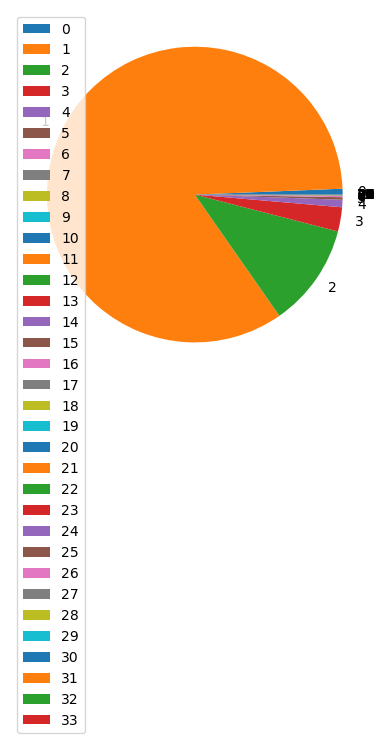

In [35]:
#target
crosstab = pd.crosstab(index = merged_df["Number of Outcome"], columns = "ratio", normalize = True)
#display(crosstab)
crosstab.plot(kind = "pie", y = "ratio")

<Axes: >

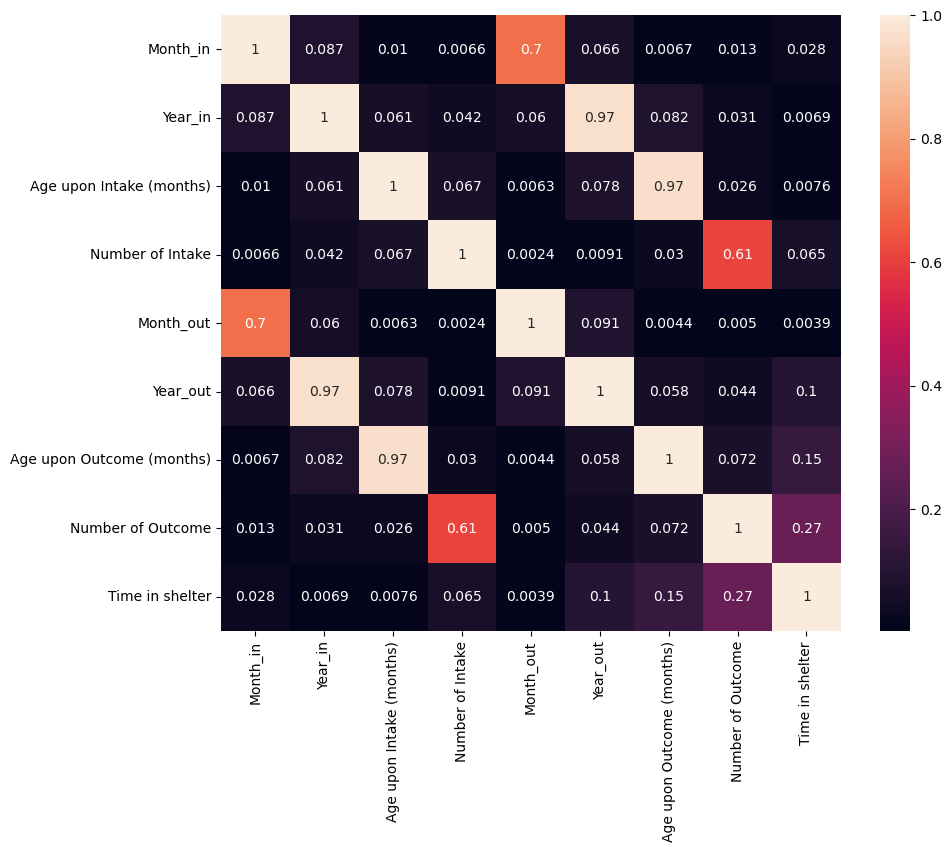

In [36]:
num_df = merged_df.select_dtypes(include=['number'])

plt.figure(figsize = (10,8))
sns.heatmap(num_df.corr().abs(), annot = True )


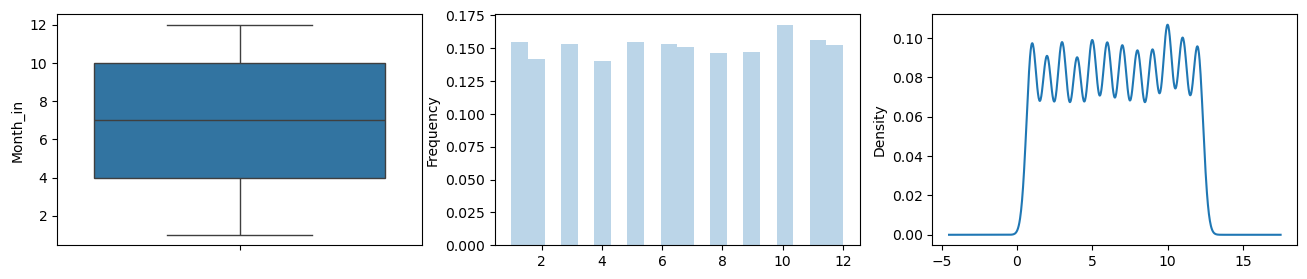

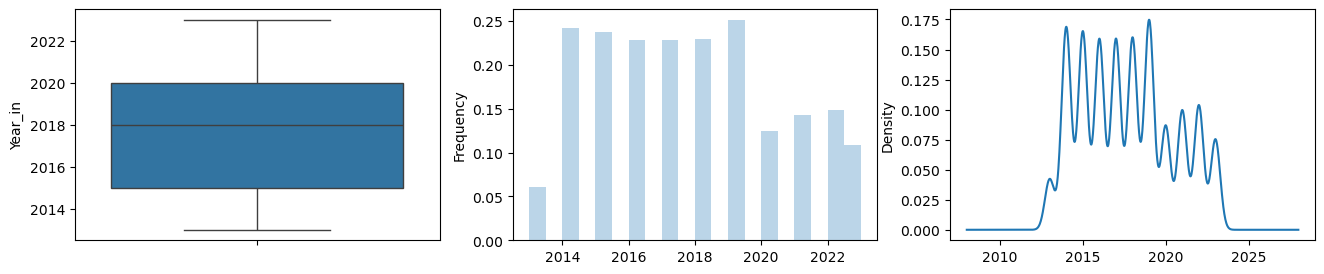

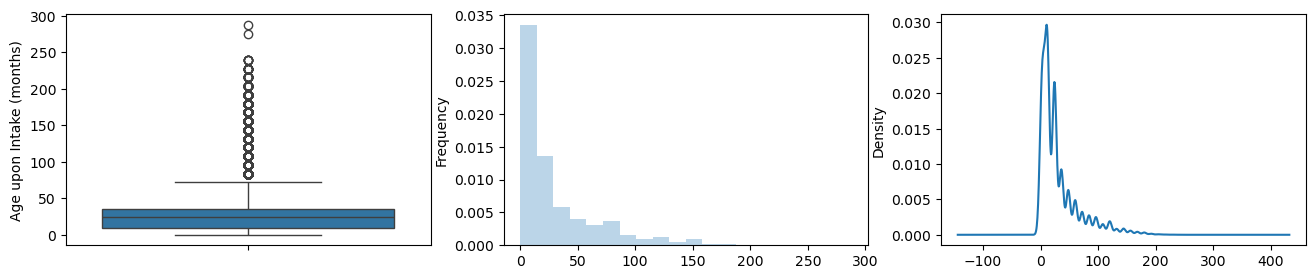

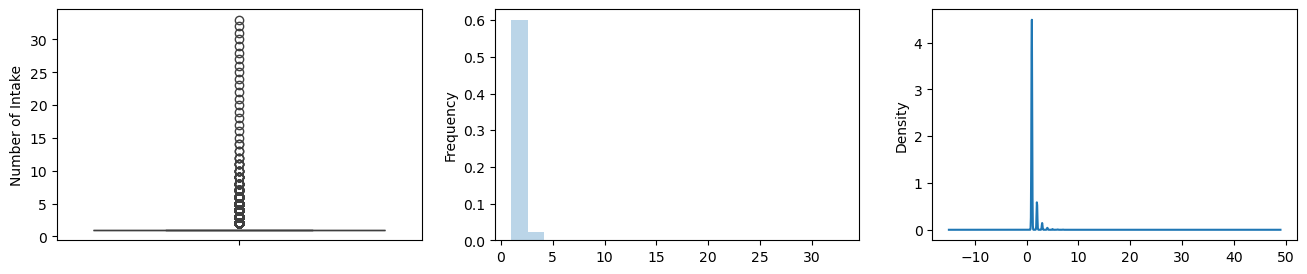

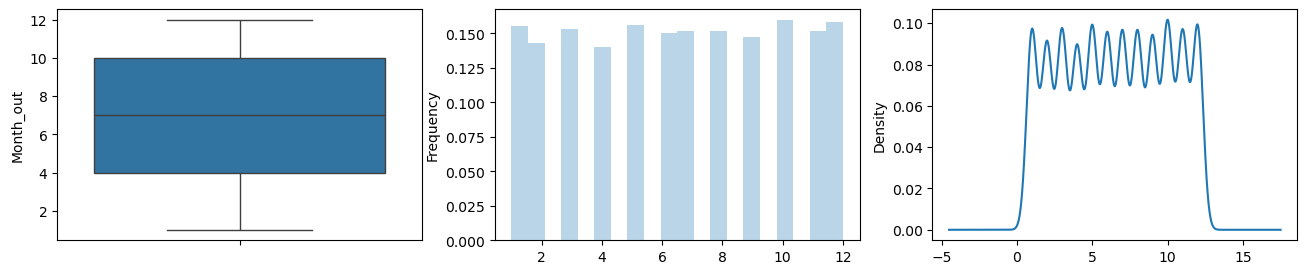

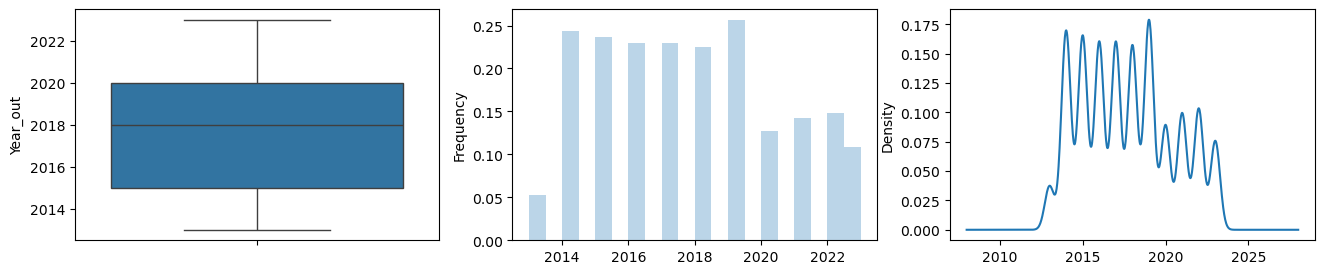

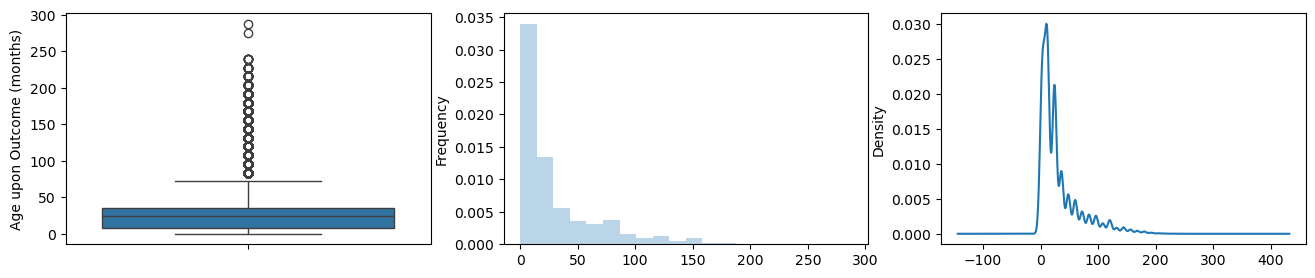

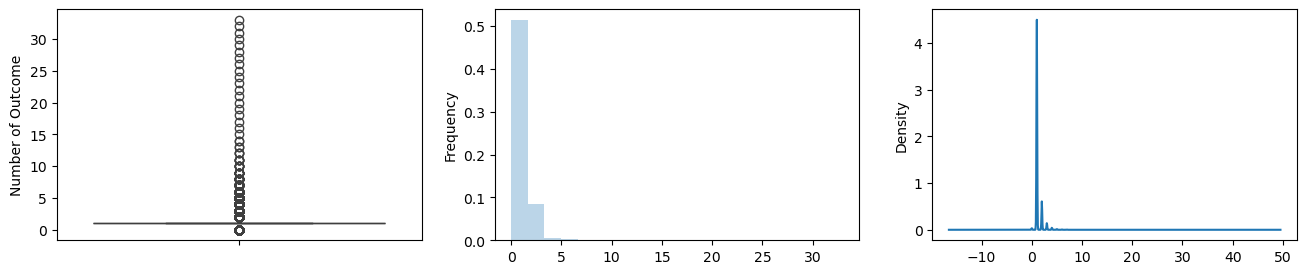

In [37]:
def numplot(col, data = num_df, save_plot = False):
    """
        Plot histogram, Boxplot and densityplot
        ARGS
            col: column to plot
            data: dataframe (default: df)
            key: Target column (default: IsBadBuy)
            save_plot (bool): save plot as png-file (default: False)
        RETURN:
            None
    """
    fig, ax = plt.subplots(ncols = 3, figsize = (16,3))
    sns.boxplot(data = data,y = col, ax = ax[0])
    data[col].plot(kind = "hist", bins = 20, ax = ax[1], alpha = 0.3, density = True)
    data[col].plot(kind = "kde", ax = ax[2])
    if save_plot:
        fig.savefig(f'numplot_{col}.png')
numcol = ['Month_in', 'Year_in', 'Age upon Intake (months)', 'Number of Intake',
       'Month_out', 'Year_out', 'Age upon Outcome (months)',
       'Number of Outcome']

for num in numcol:
    numplot(num)


In [38]:
num_df.columns

Index(['Month_in', 'Year_in', 'Age upon Intake (months)', 'Number of Intake',
       'Month_out', 'Year_out', 'Age upon Outcome (months)',
       'Number of Outcome', 'Time in shelter'],
      dtype='str')

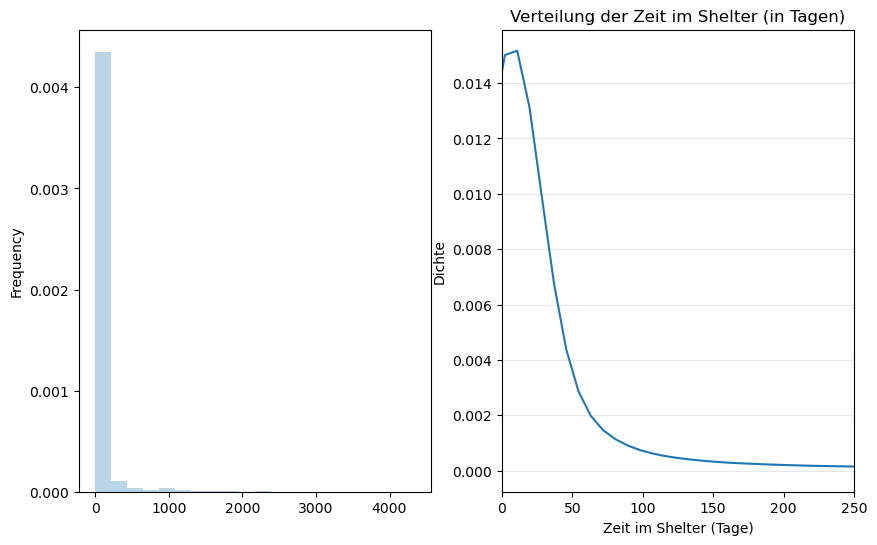

In [39]:
hours = merged_df["Time in shelter"].dt.total_seconds() / 3600/24
fig, ax = plt.subplots(ncols = 2, figsize=(10, 6))
hours.plot(kind = "hist", bins = 20, ax = ax[0], alpha = 0.3, density = True)
hours.plot(kind = "kde", ax = ax[1])
plt.title("Verteilung der Zeit im Shelter (in Tagen)")
plt.xlabel("Zeit im Shelter (Tage)")
plt.ylabel("Dichte")
plt.xlim(0,250)
plt.grid(axis='y', alpha=0.3)
plt.show()

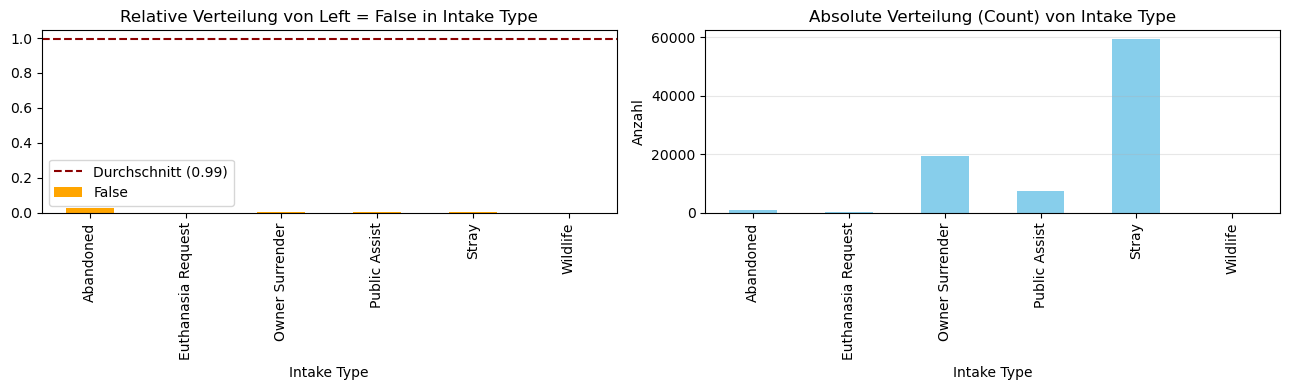

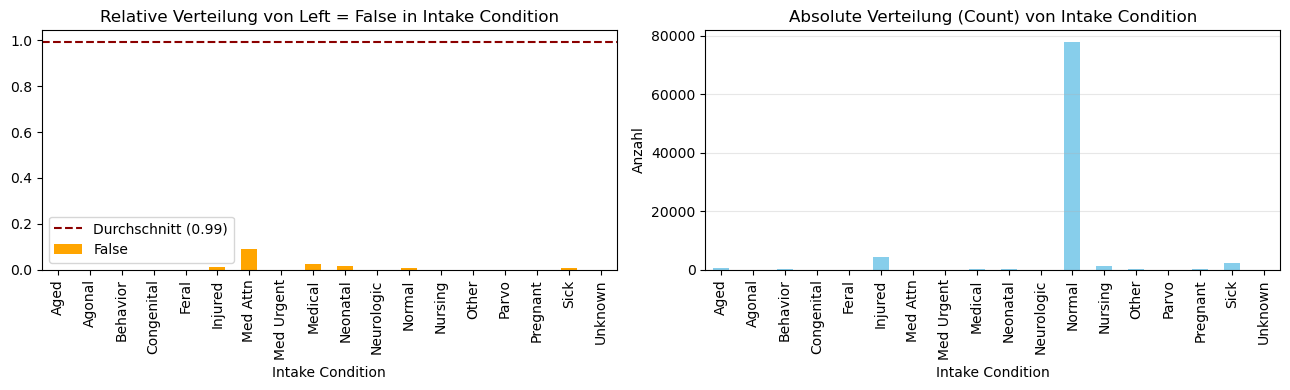

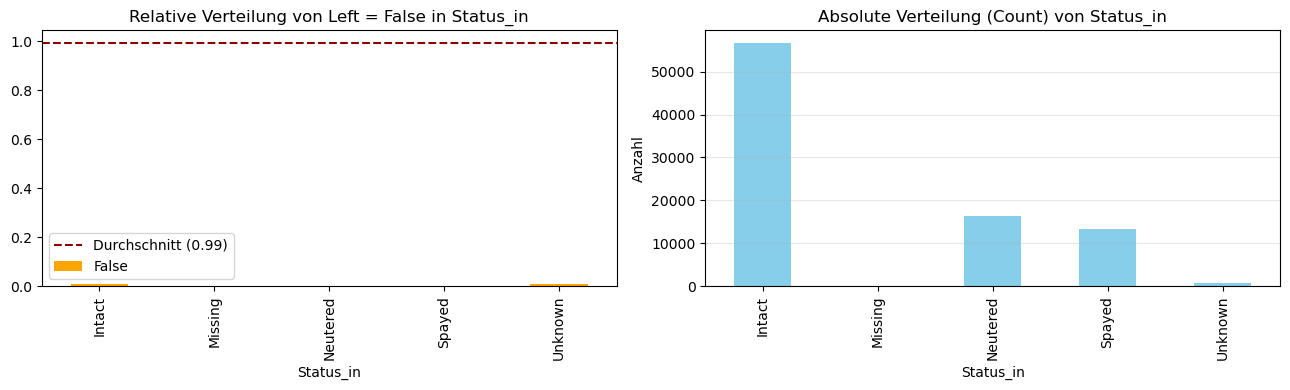

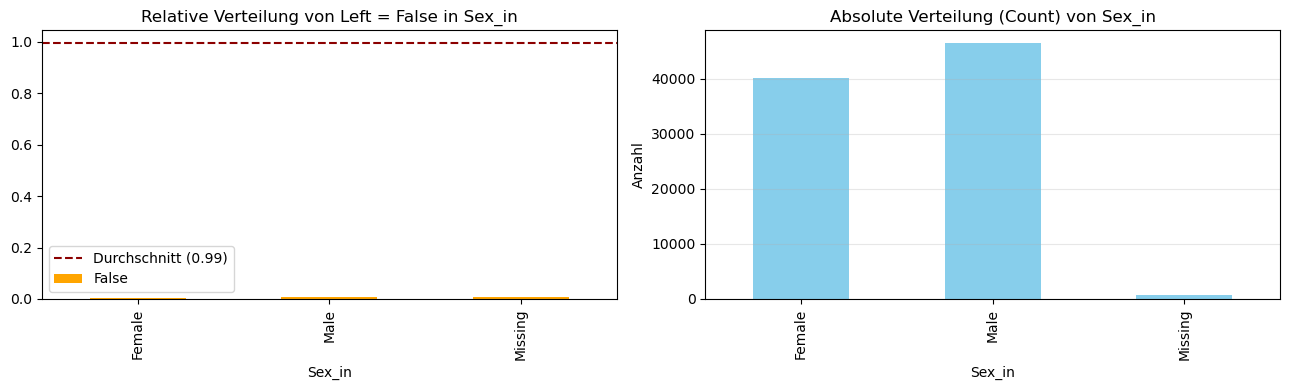

Warnung: Wert 'False' nicht in Left gefunden.


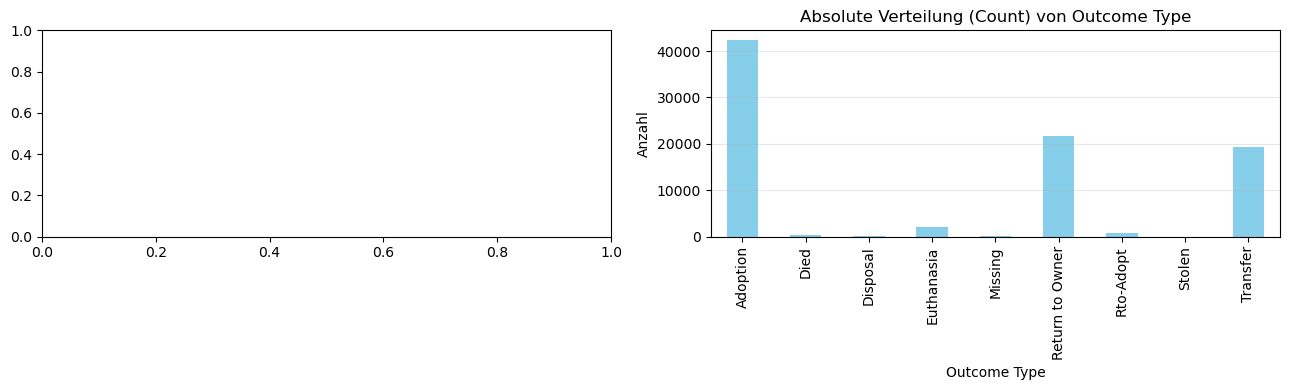

Warnung: Wert 'False' nicht in Left gefunden.


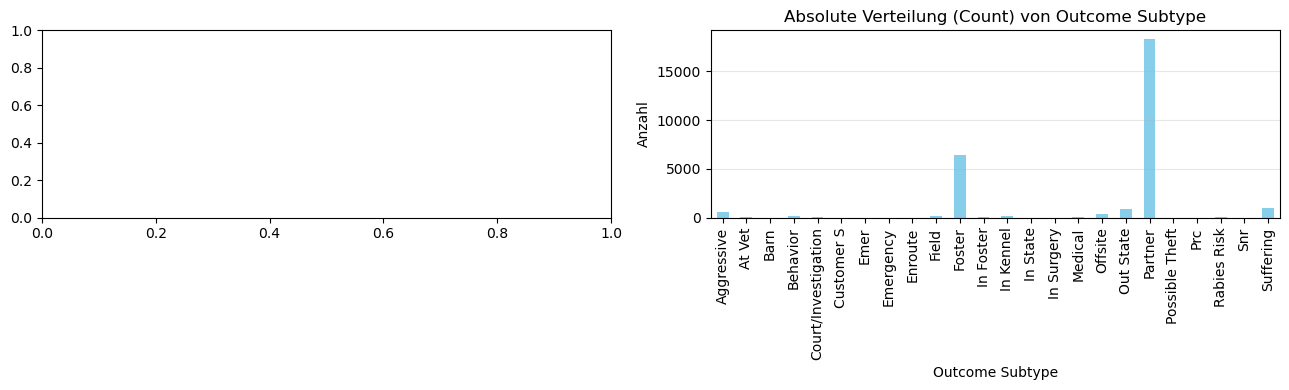

Warnung: Wert 'False' nicht in Left gefunden.


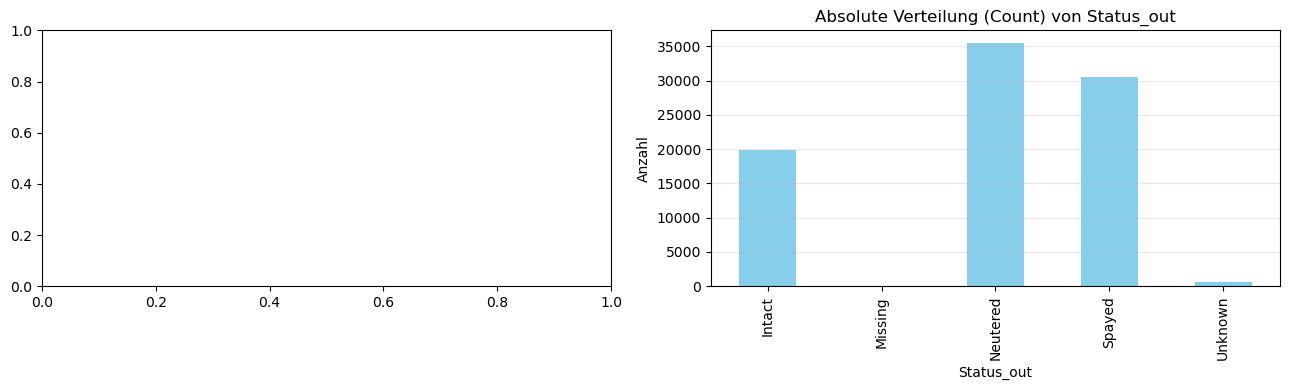

Warnung: Wert 'False' nicht in Left gefunden.


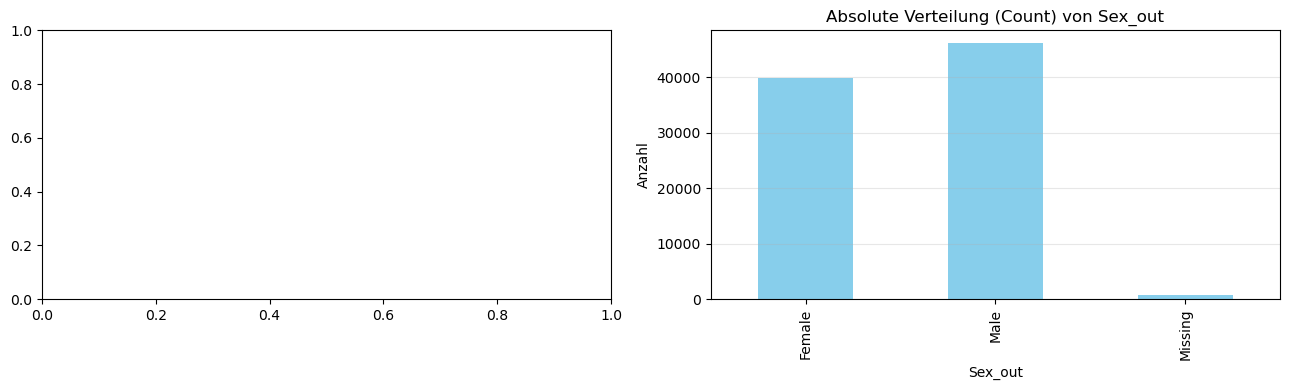

In [40]:
catcols = ['Intake Type',
       'Intake Condition', 
       'Status_in', 'Sex_in', 'Outcome Type', 'Outcome Subtype', 'Status_out',
       'Sex_out']

def catplot(col, data=merged_df, key = "Left", match=False, save_plot=False):
    '''Display 'col vs. key' barplots of... 
    ...on the left: A normalized crosstab for relative distributions.
    ...on the right: An absolute crosstab for checking the statistical significance for each category class.
    ARGS:
        col: Column name for the crosstabs' 'index'
        data (DataFrame): Data (default: df)
        key: Target column (default: 'IsBadBuy')
        match: target class to highlight (default: 1)
        save_plot (bool): Save plot as image file (default: False)
    RETURNS: None
    '''
    fig, ax = plt.subplots(figsize=(13,4), ncols=2)
    
    # Relative Verteilung
    crosstab_rel = pd.crosstab(index=data[col], columns=data[key], normalize='index')
    if match in crosstab_rel.columns:
        crosstab_rel[match].plot(kind='bar', ax=ax[0], color=['orange'], legend=False)
        ax[0].set_title(f'Relative Verteilung von {key} = {match} in {col}')
        ax[0].axhline(data[key].mean(), color="darkred", linestyle='--', label=f'Durchschnitt ({data[key].mean():.2f})')
        ax[0].legend()
    else:
        print(f"Warnung: Wert '{match}' nicht in {key} gefunden.")

    # 2. Absolute Verteilung (Einfache Häufigkeitszählung)
    # Wir zählen einfach, wie oft jede Kategorie in 'col' vorkommt
    # Keine normalize=True!
    counts = data[col].value_counts().sort_index() # sort_index für alphabetische/numerische Reihenfolge
    
    # Plot der absoluten Verteilung
    counts.plot(kind='bar', ax=ax[1], color='skyblue', legend=False)
    ax[1].set_title(f'Absolute Verteilung (Count) von {col}')
    ax[1].set_ylabel('Anzahl')
    
    # Optional: Gitterlinien für bessere Lesbarkeit
    ax[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    
    if save_plot:
        fig.savefig(f"catplot_{col}.png")
        plt.close(fig) # Speicher und schließen, um Speicher zu sparen
    else:
        plt.show()

# Ausführung
for cat in catcols:
    catplot(cat)

Auf Grund der guten Vermittlungsquote, denke ich an ein Modell, das mit der Dauer im Tierheim arbietet, oder auch an unüberwachtes lernen. Ich halte die Daten für soweit aufbereitet, dass man damit nun Arbeiten kann. Deswegen wird ein neues Notebook erstellt, in dem mit merged_df gearbeitet wird. Dazu speichere ich merged_df als pickle.

In [41]:
merged_df.to_pickle("shelter_data.pkl")